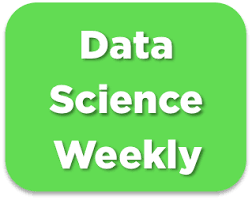

# Challenge : predict conversions 🏆🏆

This is the template that shows the different steps of the challenge. In this notebook, all the training/predictions steps are implemented for a very basic model (logistic regression with only one variable). Please use this template and feel free to change the preprocessing/training steps to get the model with the best f1-score ! May the force be with you 🧨🧨  

**For a detailed description of this project, please refer to *02-Conversion_rate_challenge.ipynb*.**

# Import libraries

In [53]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "notebook" # to be replaced by "iframe" if working on JULIE
from IPython.display import display

# Read file with labels

In [54]:
data = pd.read_csv('conversion_data_train.csv')
print('Set with labels (our train+test) :', data.shape)

Set with labels (our train+test) : (284580, 6)


In [55]:
data.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [56]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


In [57]:
data.describe(include='all')

,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.000000,284580.000000,284580,284580.000000,284580.000000
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.564203,0.685452,NaN,4.873252,0.032258
std,NaN,8.266789,0.464336,NaN,3.341995,0.176685
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000


# Explore dataset

In [58]:
# The dataset is quite big : you must create a sample of the dataset before making any visualizations !
data_sample = data.sample(10000)

# Make your model

## Choose variables to use in the model, and create train and test sets
**From the EDA, we know that the most useful feature is total_pages_visited. Let's create a baseline model by using at first only this feature : in the next cells, we'll make preprocessings and train a simple (univariate) logistic regression.**

In [59]:
target_variable = 'converted'
features_list = data.drop(columns=[target_variable]).columns

In [60]:
features_list

Index(['country', 'age', 'new_user', 'source', 'total_pages_visited'], dtype='object')

In [61]:
X = data.loc[:, features_list]
Y = data.loc[:, target_variable]

print('Explanatory variables : ', X.columns)
print()

Explanatory variables :  Index(['country', 'age', 'new_user', 'source', 'total_pages_visited'], dtype='object')



In [62]:
# Divide dataset Train set & Test set 
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



In [63]:
numeric_features = X_train.select_dtypes(exclude=['object']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns
print(numeric_features)
print(categorical_features)

Index(['age', 'new_user', 'total_pages_visited'], dtype='object')
Index(['country', 'source'], dtype='object')


## Training pipeline

In [64]:
# Put here all the preprocessings
print("Encoding categorical features and standardizing numerical features...")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train = preprocessor.fit_transform(X_train)

print("...Done")
print(X_train[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[-0.55381463 -1.47619692  0.9360016   0.          0.          1.
   0.          1.        ]
 [-0.67475586  0.6774164   1.53462601  0.          0.          1.
   0.          0.        ]
 [-1.52134449  0.6774164   0.9360016   0.          0.          1.
   0.          0.        ]
 [ 0.41371523  0.6774164  -0.85987161  0.          0.          1.
   0.          1.        ]
 [-1.15852079  0.6774164  -1.15918381  0.          0.          0.
   0.          1.        ]]


In [65]:
# Train model
print("Train model...")

classifier = XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5, random_state=0, eval_metric='logloss'
)
classifier.fit(X_train, Y_train)

print("...Done.")

Train model...


...Done.


In [66]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()

Predictions on training set...


...Done.
[0 0 0 ... 0 0 0]



## Test pipeline

In [67]:
# Use X_test, and the same preprocessings as in training pipeline, 
# but call "transform()" instead of "fit_transform" methods (see example below)

print("Encoding categorical features and standardizing numerical features...")

X_test = preprocessor.transform(X_test)
print("...Done")
print(X_test[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[-1.27946203  0.6774164   0.6366894   0.          0.          1.
   0.          0.        ]
 [ 0.05089153  0.6774164   0.03806499  0.          0.          1.
   0.          1.        ]
 [-0.31193216 -1.47619692 -0.26124721  0.          0.          1.
   0.          1.        ]
 [-0.67475586  0.6774164  -0.26124721  1.          0.          0.
   0.          0.        ]
 [ 1.62312756 -1.47619692  0.6366894   0.          0.          1.
   0.          0.        ]]


In [68]:
# Predictions on test set
print("Predictions on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()

Predictions on test set...
...Done.
[0 0 0 ... 0 0 0]



## Performance assessment

In [69]:
# WARNING : Use the same score as the one that will be used by Kaggle !
# Here, the f1-score will be used to assess the performances on the leaderboard
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))

f1-score on train set :  0.7685104907230796
f1-score on test set :  0.7606583382907


In [70]:
# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()

Confusion matrix on train set : 
[[192104    733]
 [  1937   4432]]

Confusion matrix on test set : 
[[82249   314]
 [  893  1918]]



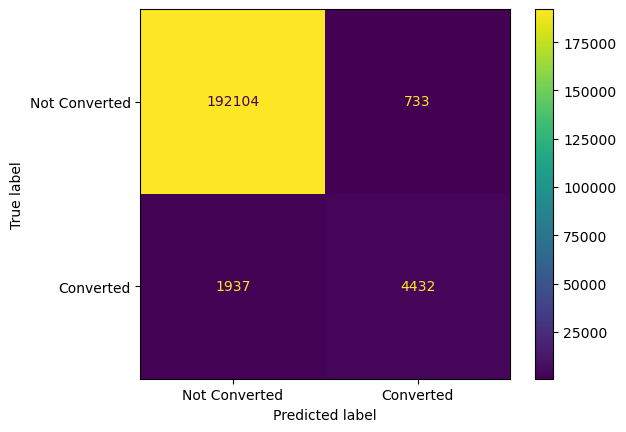

In [71]:
ConfusionMatrixDisplay.from_estimator(classifier, X_train, Y_train, display_labels=['Not Converted', 'Converted'])
plt.show()

In [72]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [1, 2, 3, 4, 5]
}

classifier_xgb = XGBClassifier(random_state=0, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=classifier_xgb, param_grid=param_grid, cv=3, refit=True, scoring='f1', verbose=1,
)
grid_search.fit(X_train, Y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score: ", grid_search.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best parameters found:  {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 2}
Best F1 score:  0.7675851164754949


In [73]:
classifier = grid_search.best_estimator_
classifier.fit(X_train, Y_train)
Y_train_pred = classifier.predict(X_train)
Y_test_pred = classifier.predict(X_test)
print(Y_train_pred[0:5])
print(Y_test_pred[0:5])

[0 0 0 0 0]
[0 0 0 0 0]


In [74]:
proba_train = classifier.predict_proba(X_train)[:, 1]
proba_test = classifier.predict_proba(X_test)[:, 1]

best_seuil = 0.5
best_f1 = 0
for seuil in np.arange(0.1, 0.9, 0.05):
    pred_test = (proba_test >= seuil).astype(int)
    f1 = f1_score(Y_test, pred_test)
    if f1 > best_f1:
        best_f1 = f1
        best_seuil = seuil

print("Seuil optimal :", best_seuil, "| F1 test :", best_f1)

seuil_optimal = best_seuil
Y_train_pred = (proba_train >= seuil_optimal).astype(int)
Y_test_pred = (proba_test >= seuil_optimal).astype(int)

Seuil optimal : 0.6000000000000002 | F1 test : 0.7689059500959693


In [75]:
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))
print()
print("recall on train set : ", recall_score(Y_train, Y_train_pred))
print("recall on test set : ", recall_score(Y_test, Y_test_pred)) 
print()
print("precision on train set : ", precision_score(Y_train, Y_train_pred))
print("precision on test set : ", precision_score(Y_test, Y_test_pred))

f1-score on train set :  0.773492758504547
f1-score on test set :  0.7689059500959693

recall on train set :  0.7211493170042392
recall on test set :  0.712557808609036

precision on train set :  0.834029417105502
precision on test set :  0.834931221342226


In [76]:
# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()

Confusion matrix on train set : 
[[191923    914]
 [  1776   4593]]

Confusion matrix on test set : 
[[82167   396]
 [  808  2003]]



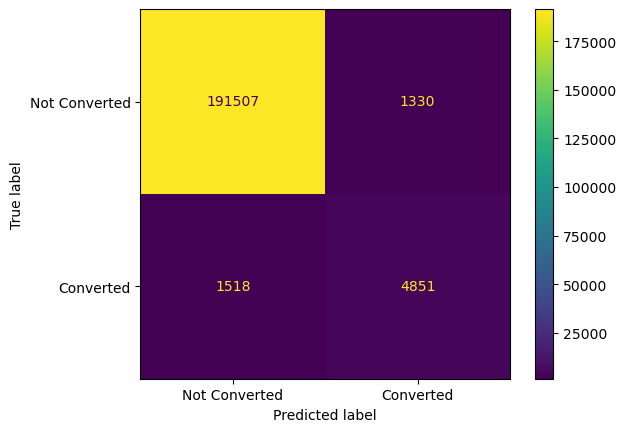

In [77]:
ConfusionMatrixDisplay.from_estimator(classifier, X_train, Y_train, display_labels=['Not Converted', 'Converted'])
plt.show()

**Our baseline model reaches a f1-score of almost 70%. Now, feel free to refine your model and try to beat this score ! 🚀🚀**

# Train best classifier on all data and use it to make predictions on X_without_labels
**Before making predictions on the file conversion_data_test.csv, let's train our model on ALL the data that was in conversion_data_train.csv. Sometimes, this allows to make tiny improvements in the score because we're using more examples to train the model.**

In [78]:
# Concatenate our train and test set to train your best classifier on all data with labels
X = np.append(X_train,X_test,axis=0)
Y = np.append(Y_train,Y_test)

classifier.fit(X,Y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [79]:
features_list

Index(['country', 'age', 'new_user', 'source', 'total_pages_visited'], dtype='object')

In [80]:
# Read data without labels
data_without_labels = pd.read_csv('conversion_data_test.csv')
print('Prediction set (without labels) :', data_without_labels.shape)

# Warning : check consistency of features_list (must be the same than the features 
# used by your best classifier)
X_without_labels = data_without_labels.loc[:, features_list]

# Convert pandas DataFrames to arrays before using scikit-learn
# print("Convert pandas DataFrames to arrays...")
# X_without_labels = X_without_labels.values
print("...Done")

print(X_without_labels.head())

Prediction set (without labels) : (31620, 5)
...Done
  country  age  new_user  source  total_pages_visited
0      UK   28         0     Seo                   16
1      UK   22         1  Direct                    5
2   China   32         1     Seo                    1
3      US   32         1     Ads                    6
4   China   25         0     Seo                    3


In [81]:
# WARNING : PUT HERE THE SAME PREPROCESSING AS FOR YOUR TEST SET
# CHECK YOU ARE USING X_without_labels
print("Encoding categorical features and standardizing numerical features...")

X_without_labels = preprocessor.transform(X_without_labels)
print("...Done")
print(X_without_labels[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[-0.31193216 -1.47619692  3.33049922  0.          1.          0.
   0.          1.        ]
 [-1.03757956  0.6774164   0.03806499  0.          1.          0.
   1.          0.        ]
 [ 0.17183277  0.6774164  -1.15918381  0.          0.          0.
   0.          1.        ]
 [ 0.17183277  0.6774164   0.3373772   0.          0.          1.
   0.          0.        ]
 [-0.67475586 -1.47619692 -0.56055941  0.          0.          0.
   0.          1.        ]]


In [82]:
# Make predictions and dump to file
# WARNING : MAKE SURE THE FILE IS A CSV WITH ONE COLUMN NAMED 'converted' AND NO INDEX !
# WARNING : FILE NAME MUST HAVE FORMAT 'conversion_data_test_predictions_[name].csv'
# where [name] is the name of your team/model separated by a '-'
# For example : [name] = AURELIE-model1
# data = {
#     'converted': classifier.predict(X_without_labels)
# }
proba_submit = classifier.predict_proba(X_without_labels)[:, 1]
data = {
    'converted': (proba_submit >= seuil_optimal).astype(int)
}

Y_predictions = pd.DataFrame(columns=['converted'],data=data)
Y_predictions.to_csv('conversion_data_test_predictions_Raphael-model3.csv ', index=False)


In [83]:
Y_predictions.value_counts()

converted
0            30747
1              873
Name: count, dtype: int64

## Analyzing the coefficients and interpreting the result
**In this template, we just trained a model with only one feature (total_pages_visited), so there's no analysis to be done about the feature importance 🤔**

**Once you've included more features in your model, please take some time to analyze the model's parameters and try to find some lever for action to improve the newsletter's conversion rate 😎😎**